In [32]:
import os
from dotenv import load_dotenv
load_dotenv

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

result = llm.invoke("Hello")
result


AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.032705963, 'completion_tokens_details': None, 'prompt_time': 0.003224067, 'prompt_tokens_details': None, 'queue_time': 0.052220193, 'total_time': 0.03593003}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f3361-07df-7861-a67e-c7db928b6554-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [33]:
from typing import Annotated,List
import operator
from typing_extensions import TypedDict,Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,SystemMessage




In [34]:
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str=Field(description="Brief overiview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

planner = llm.with_structured_output(Sections)

## Creating Workers Dynamically in Langgraph


In [35]:
from langgraph.constants import Send

class State(TypedDict):
    topic: str
    sections: List[Section]
    completed_sections: Annotated [ 
        list,operator.add
    ]
    final_report : str

## Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[List,operator.add]

/var/folders/2b/7vsbn3nj3lzcywpjqw6q6rz00000gn/T/ipykernel_4513/3536868187.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [36]:
def orchestrator(state : State):
    """Orchestrator that generates a plain for the report"""

    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic:{state['topic']}"),
        ]
    )
    print("Report Sections: ",report_sections)
    return {"sections":report_sections.sections}

def llm_call(state:WorkerState):
    """Worker writes a section  of the report"""

    ## Generate the section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section Include no preamble for each section. Use markdown formatting"
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    return {"completed_sections":[section.content]}

def assign_worker(state : State):
    """Assign a worker to each section in the plan"""

    return [Send("llm_call",{"section":s}) for s in state['sections']]

def synthesizer(state:State):
    """Synthesize full report from sections"""

    completed_sections = state["completed_sections"]

    completed_report_sections = "\n\n---\n\n".join(completed_sections)
    return {"final_report":completed_report_sections}

## Build Workflow

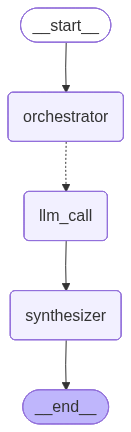

In [37]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display
orchestrator_worker_builer = StateGraph(State)

## ADD nodes

orchestrator_worker_builer.add_node("orchestrator",orchestrator)
orchestrator_worker_builer.add_node("llm_call",llm_call)
orchestrator_worker_builer.add_node("synthesizer",synthesizer)

##Add edges to the connect nodes

orchestrator_worker_builer.add_edge(START,"orchestrator")
orchestrator_worker_builer.add_conditional_edges(
    "orchestrator",assign_worker,["llm_call"]
)
orchestrator_worker_builer.add_edge("llm_call","synthesizer")
orchestrator_worker_builer.add_edge("synthesizer",END)

## Compile the workflow
orchestrator_worker = orchestrator_worker_builer.compile()

#Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [38]:
#Invoke
state = orchestrator_worker.invoke({"topic":"Create a report on AGentic AI RAGs"})

from IPython.display import Markdown
Markdown(state['final_report'])

Report Sections:  sections=[Section(name='Introduction to AGentic AI RAGs', description='Overview of AGentic AI RAGs, their purpose, and significance'), Section(name='Technical Details of AGentic AI RAGs', description='In-depth analysis of AGentic AI RAGs architecture, components, and functionality'), Section(name='Applications and Use Cases of AGentic AI RAGs', description='Exploration of various applications, benefits, and potential use cases of AGentic AI RAGs'), Section(name='Challenges and Limitations of AGentic AI RAGs', description='Discussion of the challenges, limitations, and potential drawbacks of AGentic AI RAGs'), Section(name='Future Directions and Potential of AGentic AI RAGs', description='Examination of the future potential, developments, and advancements of AGentic AI RAGs')]


### Introduction to AGentic AI RAGs
#### Overview
AGentic AI RAGs (Retrieval-Augmented Generative models) represent a significant advancement in artificial intelligence, combining the capabilities of large language models with the power of external knowledge retrieval. This integration enables AGentic AI RAGs to access and incorporate a vast amount of information from external sources, enhancing their ability to generate accurate, informative, and contextually relevant responses.

#### Purpose
The primary purpose of AGentic AI RAGs is to improve the performance and reliability of AI systems in tasks that require extensive knowledge and understanding, such as question answering, text summarization, and content creation. By leveraging external knowledge sources, AGentic AI RAGs can provide more accurate and up-to-date information, reducing the reliance on internal knowledge bases that may be outdated or incomplete.

#### Significance
The significance of AGentic AI RAGs lies in their potential to revolutionize the way AI systems interact with humans and process information. With the ability to retrieve and incorporate external knowledge in real-time, AGentic AI RAGs can:
* Enhance the accuracy and relevance of AI-generated content
* Improve the efficiency of knowledge-intensive tasks
* Enable more effective human-AI collaboration
* Facilitate the development of more sophisticated and knowledgeable AI systems

Overall, AGentic AI RAGs have the potential to transform the field of artificial intelligence, enabling the creation of more intelligent, informative, and interactive AI systems that can provide significant benefits to various industries and applications.

---

### Technical Details of AGentic AI RAGs
#### Architecture
The AGentic AI RAGs architecture is based on a modular design, comprising of several key components:
* **Knowledge Graph**: A graph-based database that stores knowledge in the form of entities, relationships, and concepts.
* **Reasoning Engine**: A rule-based system that uses logical rules to reason about the knowledge graph and generate responses.
* **Natural Language Processing (NLP) Module**: A module responsible for processing and understanding natural language input.
* **Machine Learning (ML) Module**: A module that uses machine learning algorithms to improve the performance of the reasoning engine and NLP module.

#### Components
The AGentic AI RAGs components work together to provide a robust and efficient question answering system:
* **Entity Recognition**: Identifies entities in the input text and links them to the knowledge graph.
* **Relationship Extraction**: Extracts relationships between entities in the input text and updates the knowledge graph accordingly.
* **Question Analysis**: Analyzes the input question and identifies the relevant entities, relationships, and concepts.
* **Response Generation**: Generates a response based on the analysis of the input question and the knowledge graph.

#### Functionality
The AGentic AI RAGs functionality can be broken down into several key areas:
* **Question Answering**: Provides accurate and relevant answers to user questions.
* **Knowledge Graph Updates**: Updates the knowledge graph with new information and relationships.
* **Entity Disambiguation**: Resolves ambiguities in entity recognition and linking.
* **Contextual Understanding**: Understands the context of the input question and provides relevant responses.

---

### Applications and Use Cases of AGentic AI RAGs
The applications and use cases of AGentic AI RAGs (Retrieve, Augment, Generate) are vast and diverse, with potential benefits across various industries. Some of the key applications include:
* **Content Creation**: AGentic AI RAGs can be used to generate high-quality content, such as articles, blog posts, and social media posts, with minimal human input.
* **Conversational Systems**: AGentic AI RAGs can be integrated into conversational systems, such as chatbots and virtual assistants, to provide more accurate and informative responses to user queries.
* **Language Translation**: AGentic AI RAGs can be used to improve language translation systems, allowing for more accurate and nuanced translations.
* **Text Summarization**: AGentic AI RAGs can be used to summarize long pieces of text, such as documents and articles, into concise and informative summaries.
* **Data Augmentation**: AGentic AI RAGs can be used to augment existing datasets, generating new data that can be used to improve the performance of machine learning models.
Some of the benefits of using AGentic AI RAGs include:
* **Improved Efficiency**: AGentic AI RAGs can automate many tasks, freeing up human time and resources for more complex and creative tasks.
* **Increased Accuracy**: AGentic AI RAGs can provide more accurate results than human-generated content, reducing the risk of errors and inconsistencies.
* **Enhanced Customer Experience**: AGentic AI RAGs can be used to provide personalized and interactive experiences for customers, improving customer engagement and satisfaction.
Potential use cases for AGentic AI RAGs include:
* **Customer Service**: AGentic AI RAGs can be used to power customer service chatbots, providing 24/7 support to customers.
* **Content Marketing**: AGentic AI RAGs can be used to generate high-quality content for marketing campaigns, such as blog posts and social media posts.
* **Language Learning**: AGentic AI RAGs can be used to create interactive language learning tools, providing personalized feedback and instruction to learners.
* **Research and Development**: AGentic AI RAGs can be used to assist researchers and developers, providing them with access to large amounts of data and information.

---

### Challenges and Limitations of AGentic AI RAGs
#### Technical Challenges
* **Scalability**: AGentic AI RAGs require significant computational resources, which can be a challenge for large-scale applications.
* **Data Quality**: The performance of AGentic AI RAGs is heavily dependent on the quality of the training data, which can be difficult to obtain and preprocess.
* **Explainability**: The complex nature of AGentic AI RAGs can make it challenging to interpret and explain their decisions and actions.

#### Limitations
* **Lack of Common Sense**: AGentic AI RAGs may not always possess the same level of common sense as humans, which can lead to unexpected behavior in certain situations.
* **Narrow Domain Knowledge**: AGentic AI RAGs are typically designed to operate within a specific domain or task, and may not be able to generalize to other areas.
* **Dependence on Human Input**: AGentic AI RAGs often require human input and oversight, which can be time-consuming and may limit their autonomy.

#### Potential Drawbacks
* **Bias and Fairness**: AGentic AI RAGs can perpetuate existing biases and inequalities if they are trained on biased data or designed with a particular worldview.
* **Job Displacement**: The increasing use of AGentic AI RAGs could potentially displace human workers, particularly in industries where tasks are repetitive or can be easily automated.
* **Security Risks**: AGentic AI RAGs can pose security risks if they are not designed with robust security measures, such as encryption and access controls.

---

### Future Directions and Potential of AGentic AI RAGs
#### Introduction to Future Advancements
The field of AGentic AI RAGs (Relational Agent-Based Models) is rapidly evolving, with significant potential for future developments and advancements. As AGentic AI RAGs continue to improve, we can expect to see increased applications in areas such as:
* **Complex System Modeling**: AGentic AI RAGs will be used to model and analyze complex systems, allowing for better understanding and prediction of real-world phenomena.
* **Decision Support Systems**: AGentic AI RAGs will be integrated into decision support systems, providing users with more accurate and informative recommendations.
* **Autonomous Systems**: AGentic AI RAGs will be used to control and coordinate autonomous systems, such as swarms of drones or self-driving cars.

#### Emerging Trends and Technologies
Several emerging trends and technologies are expected to shape the future of AGentic AI RAGs, including:
* **Explainable AI**: The development of explainable AI techniques will enable AGentic AI RAGs to provide transparent and interpretable results, increasing trust and adoption.
* **Edge AI**: The integration of AGentic AI RAGs with edge AI will enable real-time processing and analysis of data, reducing latency and improving performance.
* **Human-AI Collaboration**: The development of human-AI collaboration frameworks will enable AGentic AI RAGs to work effectively with humans, enhancing decision-making and problem-solving.

#### Potential Applications and Impacts
The potential applications and impacts of AGentic AI RAGs are vast and varied, including:
* **Healthcare**: AGentic AI RAGs can be used to model and analyze complex healthcare systems, optimizing resource allocation and improving patient outcomes.
* **Finance**: AGentic AI RAGs can be used to model and analyze financial systems, predicting market trends and optimizing investment strategies.
* **Environmental Sustainability**: AGentic AI RAGs can be used to model and analyze complex environmental systems, optimizing resource usage and reducing waste.

#### Challenges and Limitations
Despite the potential of AGentic AI RAGs, there are several challenges and limitations that must be addressed, including:
* **Data Quality and Availability**: AGentic AI RAGs require high-quality and relevant data to produce accurate results, which can be a challenge in many domains.
* **Scalability and Performance**: AGentic AI RAGs can be computationally intensive, requiring significant resources and infrastructure to scale.
* **Ethics and Governance**: The development and deployment of AGentic AI RAGs raises important ethical and governance questions, including issues related to transparency, accountability, and fairness.